# Minimal DREGON + RPS Notebook

1. **Load DREGON** with the new `utils.data` time-series containers (`UniformSeries`, `EventSeries`, `TimeFrame`).
2. **Import RPS predictors** (`RotorEncoder`, `RPSPredictionHead`) from the model zoo.

## 1. Imports

In [ ]:
from utils.paths import get_datasets_path


In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import librosa as lr
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

# ---------- new data utils ----------
# ---------- RPS predictor models ----------
# ---------- torch ----------
import torch

# ----
from data_processing.dregon import (
    get_geometry,
    load_dregon_timeframes,
)
from tasks.checkpoints import load_model
from utils.data import TimeFrame, UniformSeries
from utils.plots.rps_prediction import plot_sample_comparison

DATA_DIR = Path("../data")
print("imports OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
imports OK


## 2. Helper: load a `TimeFrame` from an HF dataset sample

Wraps **every** time series in the `DREGONRecord` into the new container algebra, preserving original field names.

In [5]:
def mk_standard(tf: TimeFrame):
    return TimeFrame.from_tracks(
        tracks=dict(
            audio=tf["audio"],
            rps=tf["motors_measured"],
        ),
        t_start=tf.t_start,
        t_end=tf.t_end,
        tags=tf.tags,
    )



## 3. Load DREGON (HuggingFace-style lazy dataset)

In [8]:
# Lazy metadata – no audio loaded yet
ds = load_dregon_timeframes(DATA_DIR, splits=["in_flight_noise", "in_flight_source"])
print(ds)
print("Splits:", set(tf.tags['split'] for tf in ds))
print("First sample keys:", list(ds[0]))

[TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=53254829932, phase=0.0), 'motors_measured': EventSeries(t_start_ticks=0, dur_ticks=51877295873), 'motors_command': EventSeries(t_start_ticks=0, dur_ticks=51877295873), 'imu_accel': EventSeries(t_start_ticks=0, dur_ticks=51876358913), 'imu_gyro': EventSeries(t_start_ticks=0, dur_ticks=51876358913), 'source_position': EventSeries(t_start_ticks=0, dur_ticks=51960441857)}, t_start_ticks=1519671650299304192, dur_ticks=53254829932, tags={'recording_id': 'free-flight_speech-high_room1', 'split': 'in_flight_source', 'flight_type': 'free-flight', 'source_type': 'speech', 'source_level': 'high', 'room': 'room1', 'motor_id': -1, 'motor_speed': -1, 'sample_rate': 44100}, global_data={'mic_positions': array([[ 0.042 ,  0.0615, -0.041 ],
       [-0.042 ,  0.0615,  0.041 ],
       [-0.0615,  0.042 , -0.041 ],
       [-0.0615, -0.042 ,  0.041 ],
       [-0.042 , -0.0615, -0.041 ],
       [ 0.042 , -0.0615,  0.041 ],
     

## 4. Build a `TimeFrame` from the first sample

In [13]:
sample = ds["in_flight_noise"][0]
geometry = get_geometry(DATA_DIR / "DREGON")

rec, frame = load_timeframe_from_sample(sample, geometry=geometry)  # noqa: F821

print("Recording ID:", rec.recording_id)
print("Tracks:", list(frame))
print("Duration:", frame.duration, "s")
print("Audio shape:", frame["audio"].samples.shape)
for k in frame:
    if k == "audio":
        continue
    series = frame[k]
    print(f"  {k}: {len(series)} events, values shape {series.values.shape if series.values is not None else None}")

frame = mk_standard(frame.shift(-frame.t_start))

Recording ID: free-flight_nosource_room1
Tracks: ['audio', 'motors_measured', 'motors_command', 'imu_angular_velocity', 'imu_acceleration']
Duration: 71.131451247 s
Audio shape: (8, 3136897)
  motors_measured: 59660 events, values shape (4, 59660)
  motors_command: 59660 events, values shape (4, 59660)
  imu_angular_velocity: 59660 events, values shape (3, 59660)
  imu_acceleration: 59660 events, values shape (3, 59660)


In [14]:
frame

TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=71131451247, phase=0.0), 'rps': EventSeries(t_start_ticks=5470263808, dur_ticks=63903528961)}, t_start_ticks=0, dur_ticks=71131451247, tags={})

## 5. Slice / concat demo (new utils algebra)

In [15]:
t0 = frame.t_start
t1 = t0 + 5.0          # 5-second chunk
t2 = t1 + 5.0

chunk_a = frame.slice(t0, t1)
print(chunk_a)
chunk_b = frame.slice(t1, t2)
print(chunk_b)
chunk_ab = chunk_a.concat(chunk_b)
print(chunk_ab)

# invariant: slice(a,b).concat(slice(b,c)) == slice(a,c)
assert chunk_ab.equal(frame.slice(t0, t2))
print("slice/concat invariant holds ✓")
print("chunk_a audio shape:", chunk_a["audio"].samples.shape)
print("chunk_b audio shape:", chunk_b["audio"].samples.shape)

TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=5000000000, phase=0.0)}, t_start_ticks=0, dur_ticks=5000000000, tags={})
TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=5000000000, phase=0.0), 'rps': EventSeries(t_start_ticks=470263808, dur_ticks=4529736192)}, t_start_ticks=5000000000, dur_ticks=5000000000, tags={})
TimeFrame(tracks={'rps': EventSeries(t_start_ticks=5470263808, dur_ticks=4529736192), 'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=10000000000, phase=0.0)}, t_start_ticks=0, dur_ticks=10000000000, tags={})
slice/concat invariant holds ✓
chunk_a audio shape: (8, 220500)
chunk_b audio shape: (8, 220500)


## 6. Quick look at audio + motors

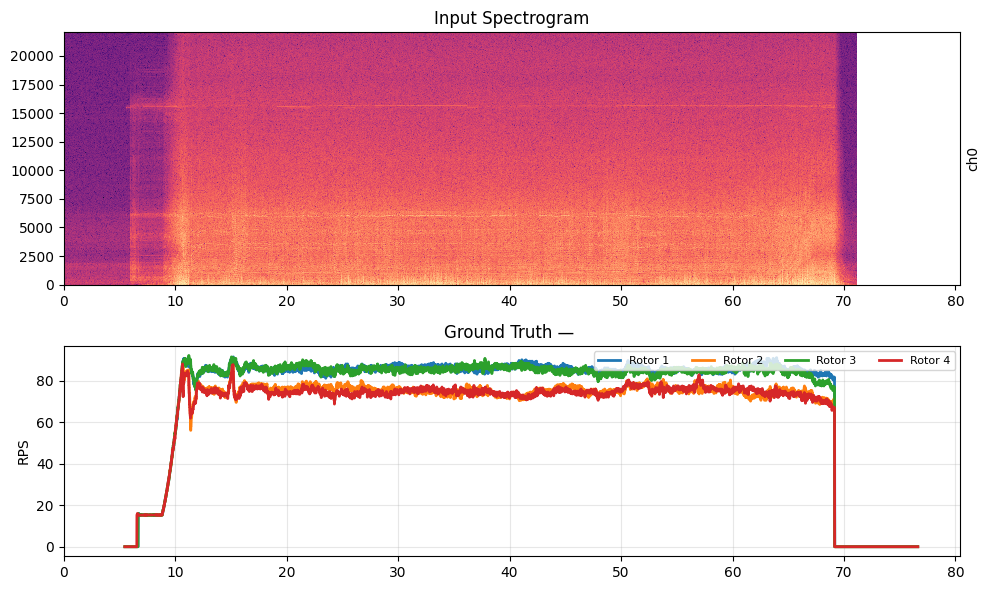

In [21]:
fig = plot_sample_comparison(sample=frame, figsize=(10, 6))

## 7. Import & inspect RPS predictor models

In [51]:
model = load_model("bi../results/rps_exp_bigru_v2/best_simple_conv_bigru_v2.pt")

## 8. Evaluate

TimeFrame(tracks={'audio': UniformSeries(sr=44100.0, t_start_ticks=0, dur_ticks=8224000000, phase=-0.5999999999767169), 'rps': EventSeries(t_start_ticks=0, dur_ticks=8224000000)}, t_start_ticks=13676000000, dur_ticks=8224000000, tags={})
13.676
13.675986394557825
(8, 362679)


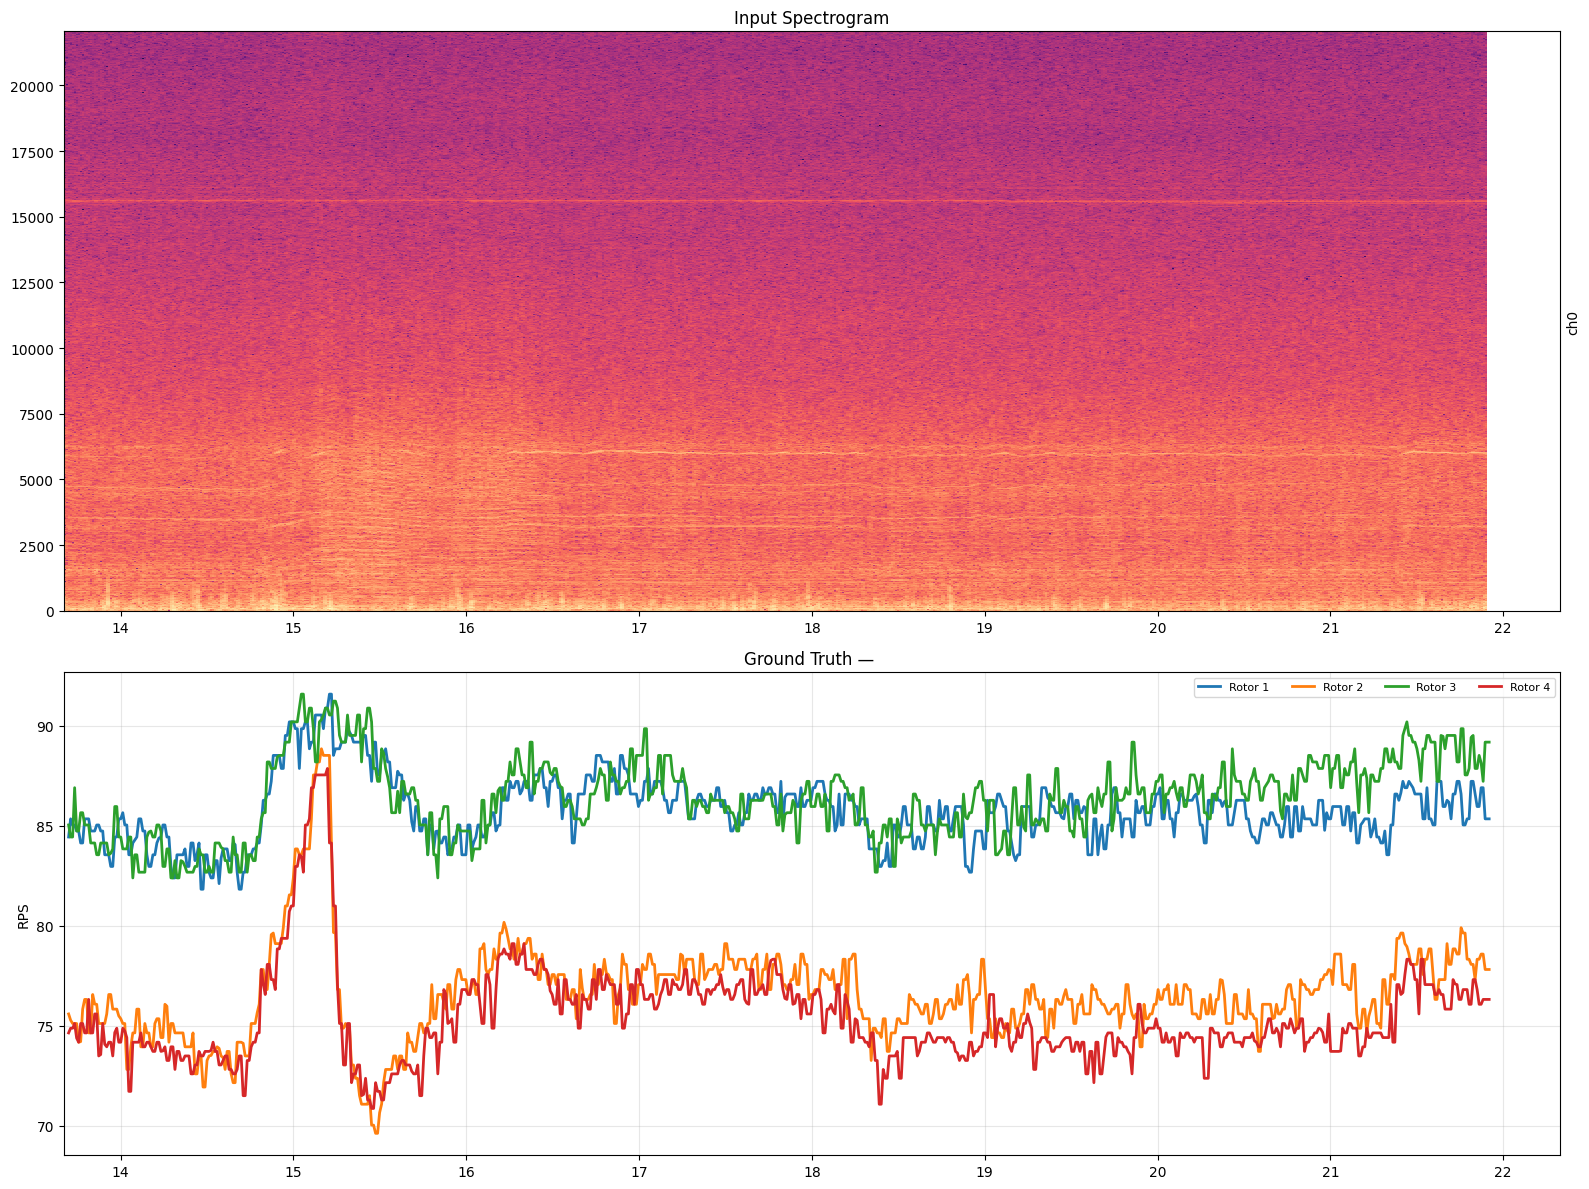

In [52]:
chunk = frame.slice(13.676, 21.900)
print(chunk)
print(chunk["audio"].t_start)
print(chunk["audio"].t_first_edge)
fig = plot_sample_comparison(sample=chunk)

input_44_1k = chunk["audio"].samples
print(input_44_1k.shape)

input_audio = chunk["audio"].resample(16000).samples

with torch.no_grad():
    res = model(torch.from_numpy(input_audio).to(dtype=torch.float32))

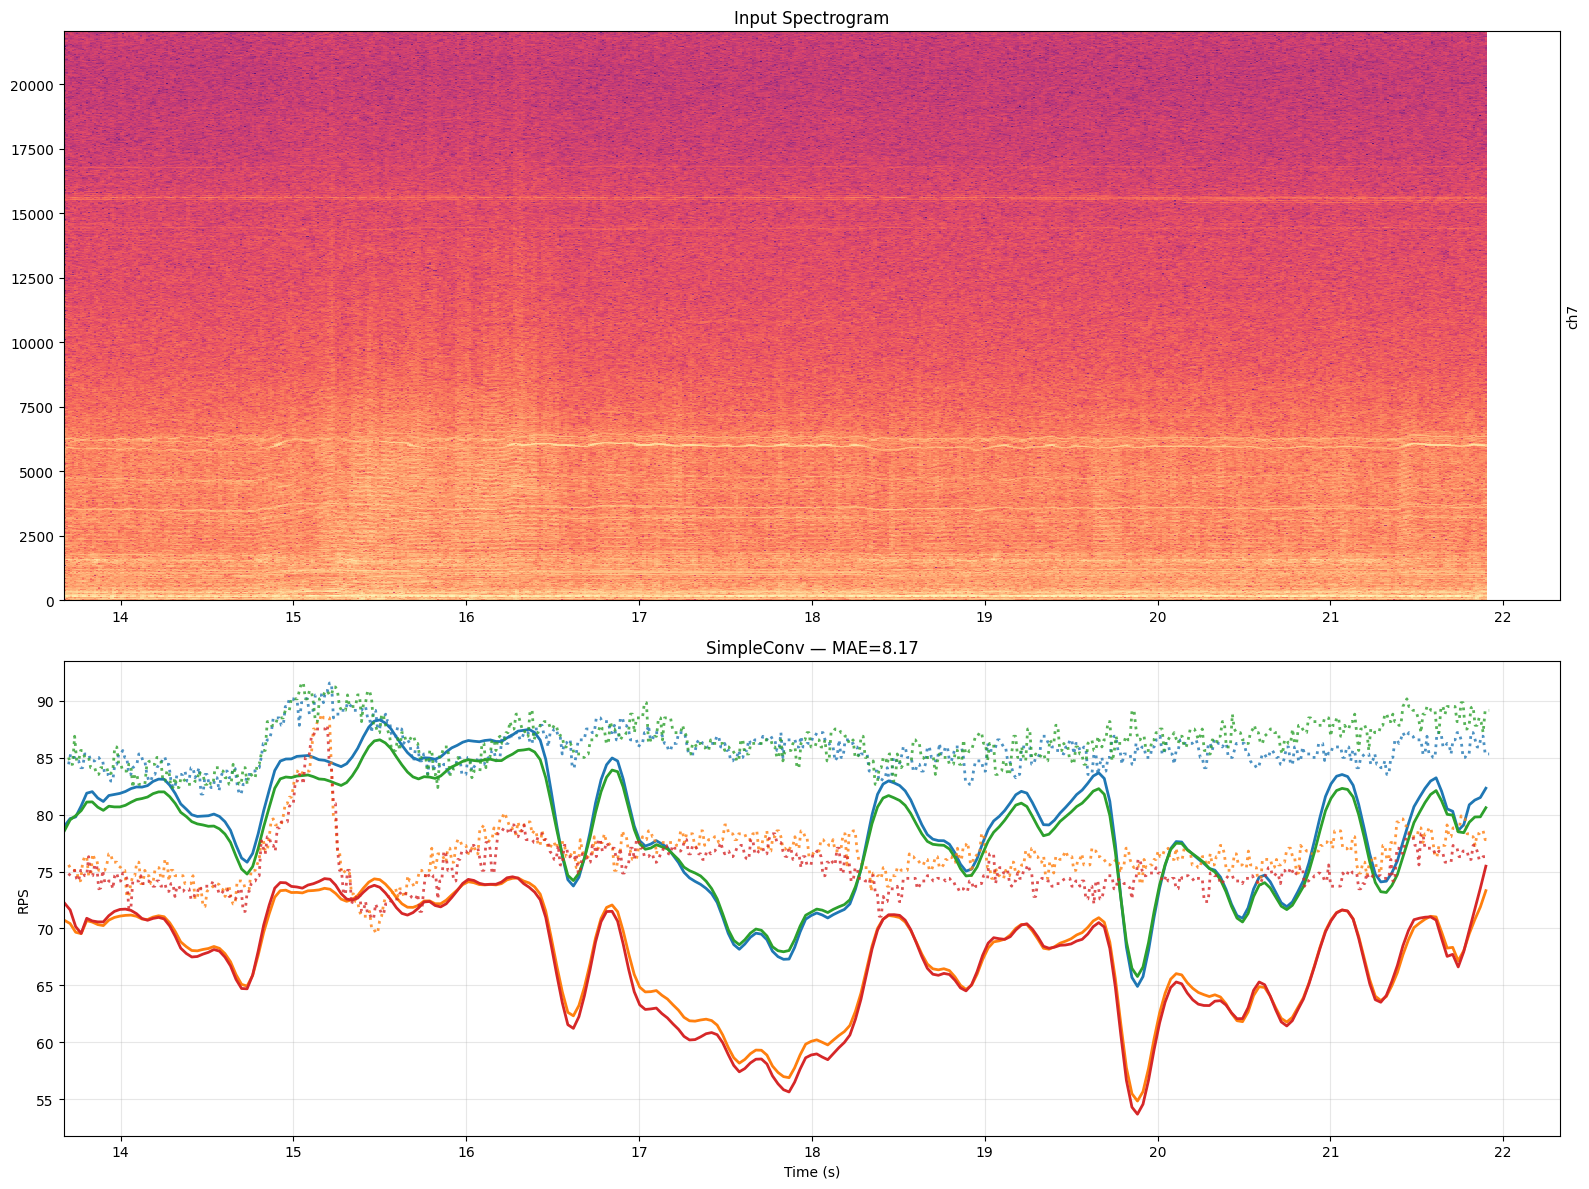

In [55]:
CH = 7
fig = plot_sample_comparison(sample=chunk, channel=CH, preds={'SimpleConv': res[CH].numpy()})

## 9. Load DREGON-LM validation samples (free-flight_nosource_room1)

Use `metadata.json` to locate validation samples cut from `free-flight_nosource_room1`.
Preserve `noise_start_time` against the original drone noise recording so each
`TimeFrame` lives on the original recording's absolute timeline.

In [119]:
import json

DREGON_LM_DIR = get_datasets_path("DREGON-LM-V3")
with open(DREGON_LM_DIR / "metadata.json") as f:
    metadata = json.load(f)

# Filter validation samples derived from free-flight_nosource_room1
valid_samples_meta = [
    s for s in metadata["valid"]
    if s["noise_source"] == "free-flight_nosource_room1_ch0"
]
print(f"Found {len(valid_samples_meta)} validation samples from free-flight_nosource_room1")

def load_dregon_lm_sample_as_timeframe(meta_entry):
    sample_dir = DREGON_LM_DIR / "valid" / meta_entry["id"]

    # Load audio at native 16 kHz
    mixture, sr = lr.load(str(sample_dir / "mixture.wav"), sr=None, mono=False)
    noise, _   = lr.load(str(sample_dir / "noise.wav"),   sr=None, mono=False)
    vocals, _  = lr.load(str(sample_dir / "vocals.wav"),  sr=None, mono=False)

    # UniformSeries expects (N_samples, n_channels); force 2-D for mono
    if mixture.ndim == 1:
        mixture = mixture[:, None]
        noise   = noise[:, None]
        vocals  = vocals[:, None]
    else:
        mixture = mixture.T
        noise   = noise.T
        vocals  = vocals.T

    # Load RPS — regular sampled at motor_sample_rate, shape (4, N)
    rps = np.load(sample_dir / "rps.npy")
    motor_sr = meta_entry.get("motor_sample_rate", sr * float(rps.shape[-1]) / float(mixture.shape[0]) )

    # Anchor to the original recording's timeline
    t_start = meta_entry.get("noise_start_time", 0.0)

    tracks = {
        "audio": UniformSeries.from_samples(mixture, sr=sr, t_start=t_start),
        "noise"  : UniformSeries.from_samples(noise,   sr=sr, t_start=t_start),
        "vocals" : UniformSeries.from_samples(vocals,  sr=sr, t_start=t_start),
        "motors_measured"    : UniformSeries.from_samples(rps.T,   sr=motor_sr, t_start=t_start),
    }

    tf = TimeFrame.from_tracks(tracks)
    return tf

valid_timeframes = []
for meta in valid_samples_meta[:5]:   # demo: first 5
    tf = load_dregon_lm_sample_as_timeframe(meta)
    valid_timeframes.append((meta["id"], tf))
    print(f"{meta['id']}: t_start={tf.t_start:.3f}s, t_end={tf.t_end:.3f}s, dur={tf.duration:.3f}s")

print(f"\nLoaded {len(valid_timeframes)} TimeFrames")
print("First sample tracks:", list(valid_timeframes[0][1]))

Found 78 validation samples from free-flight_nosource_room1
sample_00000: t_start=0.000s, t_end=1.000s, dur=1.000s
sample_00010: t_start=0.000s, t_end=1.000s, dur=1.000s
sample_00015: t_start=0.000s, t_end=1.000s, dur=1.000s
sample_00020: t_start=0.000s, t_end=1.000s, dur=1.000s
sample_00021: t_start=0.000s, t_end=1.000s, dur=1.000s

Loaded 5 TimeFrames
First sample tracks: ['audio', 'noise', 'vocals', 'motors_measured']


In [57]:
IDX = 3

plot_audio_and_rps(valid_timeframes[IDX][1])  # noqa: F821

NameError: name 'valid_timeframes' is not defined

In [124]:
chunk_2 = valid_timeframes[IDX][1]
input_audio = chunk_2["audio"].samples.T
input_audio.shape

(1, 16000)

In [125]:
with torch.no_grad():
    res = model(torch.from_numpy(input_audio).to(dtype=torch.float32))

In [126]:
print(res.shape)
print(res)

torch.Size([1, 4, 32])
tensor([[[86.1015, 84.4191, 84.4840, 84.7958, 83.7894, 83.7955, 84.4505,
          84.5167, 84.2477, 84.2986, 85.1367, 85.6295, 85.6243, 85.4071,
          85.3764, 84.7177, 84.1293, 84.1024, 84.0244, 84.0278, 84.5482,
          84.6884, 84.0570, 82.6965, 83.1809, 82.3311, 81.3435, 81.6908,
          81.1348, 80.4544, 79.9940, 81.5089],
         [78.3202, 77.0594, 77.4140, 77.2816, 77.6411, 77.5111, 78.0268,
          77.7912, 77.6650, 77.8565, 78.7507, 79.1964, 79.2157, 79.1265,
          79.1630, 78.4243, 77.7370, 77.7130, 77.5656, 77.4035, 77.8039,
          78.1543, 77.7551, 76.4233, 77.2046, 76.9132, 76.1077, 76.2893,
          75.6419, 75.5064, 74.3052, 75.0174],
         [84.3948, 82.8153, 82.9027, 83.1553, 82.1636, 82.1696, 82.8052,
          82.8750, 82.6153, 82.6747, 83.5063, 83.9890, 83.9703, 83.7444,
          83.7097, 83.0583, 82.4763, 82.4545, 82.3874, 82.3977, 82.9105,
          83.0481, 82.4267, 81.0721, 81.5621, 80.7690, 79.7962, 80.0919,
       

(32, 4)


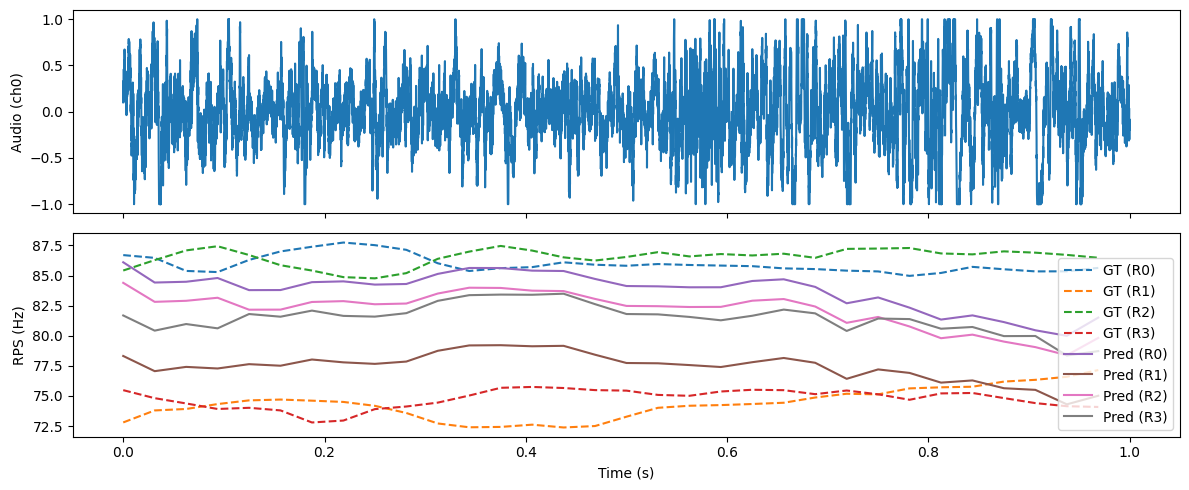

In [127]:
res_tf = UniformSeries.from_samples(samples=res[0].T, sr=res.shape[-1]/chunk_2.duration, t_start=chunk_2.t_start)
plot_audio_and_rps(chunk_2, prediction=res_tf, channel=0)  # noqa: F821

4